## Julieta

## Cargas las librerías necesarias

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from datetime import datetime

## Descarga de cadena de opciones
- S0 es el precio actual del spot
- exp_list[2] toma el tercer vencimiento disponible (aproximadamente 1 mes)
- T convierte los días restantes a fracción de año porque Black-Scholes lo requiere así
- chain.calls y chain.puts son tablas con todos los contratos disponibles para ese vencimiento

muestra las primeras filas para que el grader vea que los datos son reales.

In [ ]:
ticker = "TSLA"
stock  = yf.Ticker(ticker)
S0     = stock.history(period="1d")['Close'].iloc[-1]
r      = 0.0525

exp_list   = stock.options
target_exp = exp_list[2]
T = (datetime.strptime(target_exp, '%Y-%m-%d') - datetime.now()).days / 365

chain = stock.option_chain(target_exp)
calls, puts = chain.calls, chain.puts

cols = ['strike', 'lastPrice', 'impliedVolatility', 'volume', 'openInterest']

print(f"Activo        : {ticker}")
print(f"Precio actual : ${S0:.2f}")
print(f"Vencimiento   : {target_exp}  (T = {T:.4f} años = {round(T*365)} días)")
print(f"Tasa libre    : {r:.2%}")
print()
print("── Calls (primeras 8 filas) ──")
display(calls[cols].head(8).reset_index(drop=True))
print("── Puts (primeras 8 filas) ──")
display(puts[cols].head(8).reset_index(drop=True))

Activo        : TSLA
Precio actual : $445.00
Vencimiento   : 2026-05-18  (T = 0.0137 años = 5 días)
Tasa libre    : 5.25%

── Calls (primeras 8 filas) ──


,strike,lastPrice,impliedVolatility,volume,openInterest
0,250.0,141.92,1.787110,NaN,40
1,335.0,90.70,0.854494,NaN,1
2,340.0,50.85,0.936524,NaN,1
3,350.0,96.60,0.882814,2.0,3
4,352.5,76.58,0.835451,1.0,1
5,355.0,71.18,0.813478,3.0,18
6,357.5,83.02,0.822756,5.0,1
7,360.0,86.83,0.807131,15.0,15


── Puts (primeras 8 filas) ──


,strike,lastPrice,impliedVolatility,volume,openInterest
0,250.0,0.06,1.429690,49.0,364.0
1,260.0,0.02,1.386722,1.0,5.0
2,270.0,0.22,1.308597,NaN,2.0
3,280.0,0.07,1.230473,5.0,60.0
4,290.0,0.05,1.152348,20.0,1.0
5,300.0,0.08,1.078130,1533.0,22.0
6,310.0,0.08,1.011724,486.0,2.0
7,320.0,0.10,0.941407,2406.0,80.0


## Funciones genéricas

- payoff_estrategia recorre cada leg de la estrategia y suma los P&L individuales
- una call, el payoff bruto es max(ST - K, 0)
- una put, max(K - ST, 0)
- Multiplica por posicion (+1 si long, -1 si short) y resta la prima pagada o suma la cobrada = el resultado es el P&L neto total al vencimiento
- graficar_estrategia dibuja la gráfica: línea azul del P&L, línea negra en cero, línea verde para S0, líneas grises para los strikes y sombreado verde/rojo para zonas de ganancia y pérdida.

In [ ]:
def payoff_estrategia(S_range, legs):
    """
    P&L neto al vencimiento para cualquier combinación de legs.
    Cada leg: {'tipo':'call'/'put', 'K':float, 'prima':float, 'posicion':+1/-1}
    """
    total = np.zeros(len(S_range))
    for leg in legs:
        if leg['tipo'] == 'call':
            payoff = np.maximum(S_range - leg['K'], 0)
        else:
            payoff = np.maximum(leg['K'] - S_range, 0)
        total += leg['posicion'] * (payoff - leg['prima'])
    return total


def graficar_estrategia(S_range, pnl, titulo, S0=None, K_lines=None):
    """Grafica una estrategia con formato estándar (estilo Clase 19/21)."""
    plt.figure(figsize=(9, 5))
    plt.plot(S_range, pnl, color='steelblue', linewidth=2,
             label='P&L al vencimiento')
    plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
    if S0 is not None:
        plt.axvline(S0, color='green', linewidth=1.0, linestyle='--',
                    label=f'S0={S0:.2f}')
    if K_lines:
        for k, label in K_lines:
            plt.axvline(k, color='gray', linewidth=0.8, linestyle=':',
                        label=label)
    plt.fill_between(S_range, pnl, 0, where=(pnl > 0),
                     alpha=0.15, color='green', label='Ganancia')
    plt.fill_between(S_range, pnl, 0, where=(pnl < 0),
                     alpha=0.15, color='red', label='Pérdida')
    plt.xlabel('Precio al vencimiento $S_T$')
    plt.ylabel('P&L ($)')
    plt.title(titulo)
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## Griegas
Implementa Black-Scholes para calcular las 5 griegas, primero calcula d1 y d2:

- Delta: sensibilidad del precio de la opción ante movimientos del subyacente
- Gamma: velocidad a la que cambia la Delta
- Vega: sensibilidad ante cambios en volatilidad implícita (dividida entre 100 para expresarla por 1% de IV)
- Theta: erosión diaria por paso del tiempo (dividida entre 365)
- Rho: sensibilidad ante cambios en la tasa de interés (dividida entre 100)


In [ ]:
def greeks(S, K, r, T, sigma, option='call'):
    if T <= 0 or sigma <= 0:
        return {k: 0 for k in ['delta', 'gamma', 'vega', 'theta', 'rho']}
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))
    vega  = S * norm.pdf(d1) * np.sqrt(T) / 100
    if option == 'call':
        delta = norm.cdf(d1)
        theta = (-S * norm.pdf(d1) * sigma / (2 * np.sqrt(T))
                 - r * K * np.exp(-r * T) * norm.cdf(d2)) / 365
        rho   =  K * T * np.exp(-r * T) * norm.cdf(d2)  / 100
    else:
        delta = norm.cdf(d1) - 1
        theta = (-S * norm.pdf(d1) * sigma / (2 * np.sqrt(T))
                 + r * K * np.exp(-r * T) * norm.cdf(-d2)) / 365
        rho   = -K * T * np.exp(-r * T) * norm.cdf(-d2) / 100
    return {'delta': delta, 'gamma': gamma, 'vega': vega,
            'theta': theta, 'rho': rho}

## Contratos

- Bull Call Spread buscas la call cuyo strike está más cerca del 95% del precio actual (ITM, que compras) y la call más cerca del 105% (OTM, que vendes)
- argsort()[:1] ordena por distancia al objetivo y toma el más cercano, extraes strike, prima e IV de cada contrato
- Long Straddle buscas la call más cercana al precio actual (ATM) y luego la put con exactamente ese mismo strike

Ambas piernas comparten el mismo K

In [ ]:
# ── ESTRATEGIA 1: Bull Call Spread ──────────────────────────────────────────
long_c  = calls.iloc[(calls['strike'] - S0 * 0.95).abs().argsort()[:1]]
short_c = calls.iloc[(calls['strike'] - S0 * 1.05).abs().argsort()[:1]]

k1, p1, sig1 = (long_c['strike'].iloc[0],
                long_c['lastPrice'].iloc[0],
                long_c['impliedVolatility'].iloc[0])
k2, p2, sig2 = (short_c['strike'].iloc[0],
                short_c['lastPrice'].iloc[0],
                short_c['impliedVolatility'].iloc[0])

net_cost_bull = p1 - p2

print("══ BULL CALL SPREAD ── contratos seleccionados ══")
print(f"  LEG 1 · LONG  Call  K={k1:>7.2f} | Prima={p1:>7.2f} | IV={sig1:.4f}")
print(f"  LEG 2 · SHORT Call  K={k2:>7.2f} | Prima={p2:>7.2f} | IV={sig2:.4f}")
print(f"  Prima neta pagada  : ${net_cost_bull:.2f}")
print(f"  Vencimiento: {target_exp}")

# ── ESTRATEGIA 2: Long Straddle ──────────────────────────────────────────────
atm_call_row = calls.iloc[(calls['strike'] - S0).abs().argsort()[:1]]
k_atm        = atm_call_row['strike'].iloc[0]
p_c_atm      = atm_call_row['lastPrice'].iloc[0]
sig_c_atm    = atm_call_row['impliedVolatility'].iloc[0]

atm_put_row  = puts[puts['strike'] == k_atm]
p_p_atm      = atm_put_row['lastPrice'].iloc[0]
sig_p_atm    = atm_put_row['impliedVolatility'].iloc[0]

cost_straddle = p_c_atm + p_p_atm

print()
print("══ LONG STRADDLE ── contratos seleccionados ══")
print(f"  LEG 1 · LONG Call ATM  K={k_atm:>7.2f} | Prima={p_c_atm:>7.2f} | IV={sig_c_atm:.4f}")
print(f"  LEG 2 · LONG Put  ATM  K={k_atm:>7.2f} | Prima={p_p_atm:>7.2f} | IV={sig_p_atm:.4f}")
print(f"  Costo total        : ${cost_straddle:.2f}")
print(f"  Vencimiento: {target_exp}")

══ BULL CALL SPREAD ── contratos seleccionados ══
  LEG 1 · LONG  Call  K= 422.50 | Prima=  26.90 | IV=0.5304
  LEG 2 · SHORT Call  K= 467.50 | Prima=   5.60 | IV=0.5206
  Prima neta pagada  : $21.30
  Vencimiento: 2026-05-18

══ LONG STRADDLE ── contratos seleccionados ══
  LEG 1 · LONG Call ATM  K= 445.00 | Prima=  12.10 | IV=0.4963
  LEG 2 · LONG Put  ATM  K= 445.00 | Prima=  11.72 | IV=0.4801
  Costo total        : $23.82
  Vencimiento: 2026-05-18


## Payoff Bull Call Spread
Defines los dos legs con sus posiciones (+1 long, -1 short) y calculas el P&L con la función genérica con los tres valores clave:

- Breakeven = K1 + prima neta pagada (el precio mínimo al que recuperas el costo)
- Ganancia máxima = (K2 - K1) - prima neta (limitada porque vendiste la call superior)
- Pérdida máxima = prima neta pagada (limitada porque compraste la call inferior)

Prima neta pagada  : $21.30
Ganancia máxima    : $23.70  (si ST ≥ 467.5)
Pérdida máxima     : $-21.30  (si ST ≤ 422.5)
Break-even         : $443.80


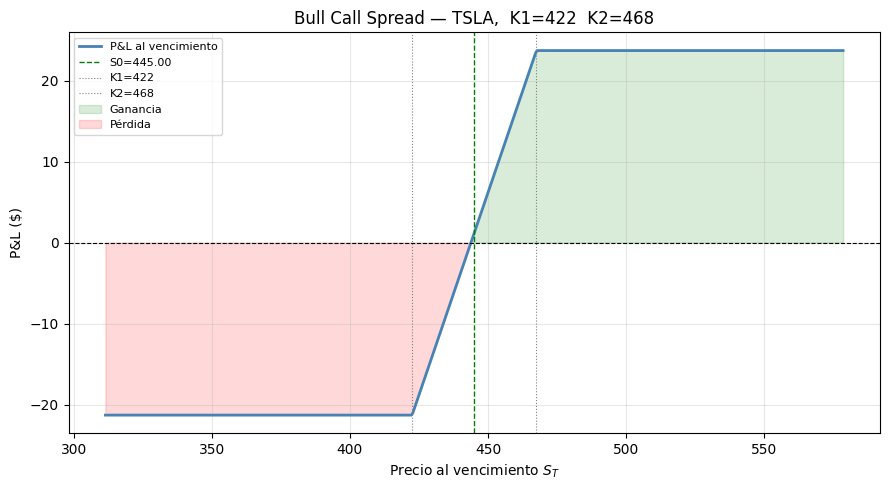

In [ ]:
S_range = np.linspace(S0 * 0.70, S0 * 1.30, 500)

legs_bull = [
    {'tipo': 'call', 'K': k1, 'prima': p1, 'posicion': +1},
    {'tipo': 'call', 'K': k2, 'prima': p2, 'posicion': -1},
]
pnl_bull = payoff_estrategia(S_range, legs_bull)

be_bull         = k1 + net_cost_bull
max_profit_bull = (k2 - k1) - net_cost_bull
max_loss_bull   = -net_cost_bull

print(f"Prima neta pagada  : ${net_cost_bull:.2f}")
print(f"Ganancia máxima    : ${max_profit_bull:.2f}  (si ST ≥ {k2})")
print(f"Pérdida máxima     : ${max_loss_bull:.2f}  (si ST ≤ {k1})")
print(f"Break-even         : ${be_bull:.2f}")

graficar_estrategia(S_range, pnl_bull,
                    f'Bull Call Spread — {ticker},  K1={k1:.0f}  K2={k2:.0f}',
                    S0=S0,
                    K_lines=[(k1, f'K1={k1:.0f}'), (k2, f'K2={k2:.0f}')])

## Payoff Long Straddle
Defines los dos legs como long call + long put sobre el mismo strike ATM. Los valores clave son:

- Breakeven inferior = K - costo total (el precio tiene que bajar tanto como costó el straddle)
- Breakeven superior = K + costo total (simétrico hacia arriba)
- Pérdida máxima = costo total (si el precio se queda exactamente en K al vencimiento, ambas opciones expiran sin valor)
- Ganancia máxima = ilimitada (crece con la magnitud del movimiento en cualquier dirección)

Costo total        : $23.82
Break-even sup.    : $468.82
Break-even inf.    : $421.18
Pérdida máxima     : $-23.82  (si ST = 445.0)
Ganancia máxima    : Ilimitada


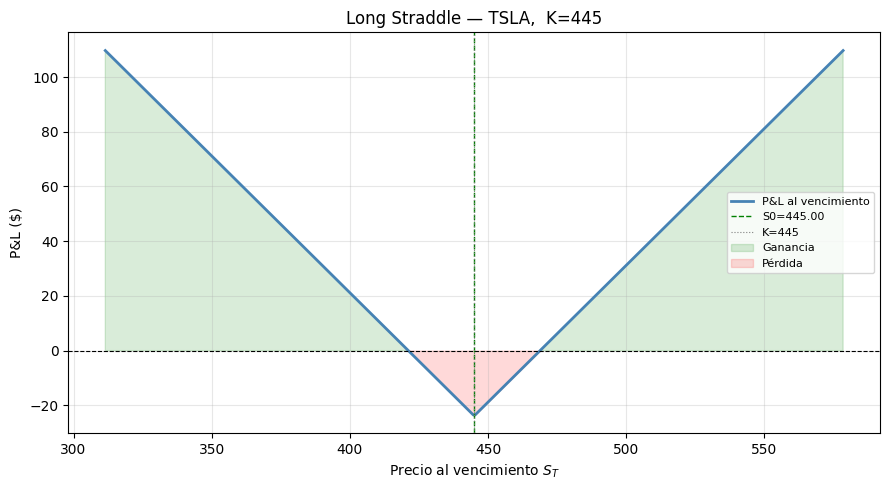

In [ ]:
legs_straddle = [
    {'tipo': 'call', 'K': k_atm, 'prima': p_c_atm, 'posicion': +1},
    {'tipo': 'put',  'K': k_atm, 'prima': p_p_atm, 'posicion': +1},
]
pnl_straddle = payoff_estrategia(S_range, legs_straddle)

be_s_low          = k_atm - cost_straddle
be_s_high         = k_atm + cost_straddle
max_loss_straddle = -cost_straddle

print(f"Costo total        : ${cost_straddle:.2f}")
print(f"Break-even sup.    : ${be_s_high:.2f}")
print(f"Break-even inf.    : ${be_s_low:.2f}")
print(f"Pérdida máxima     : ${max_loss_straddle:.2f}  (si ST = {k_atm})")
print(f"Ganancia máxima    : Ilimitada")

graficar_estrategia(S_range, pnl_straddle,
                    f'Long Straddle — {ticker},  K={k_atm:.0f}',
                    S0=S0,
                    K_lines=[(k_atm, f'K={k_atm:.0f}')])

## Griegas Bull Call Spread
Calculas las griegas de cada leg por separado con Black-Scholes usando los parámetros reales descargados (S0, strike real, T, r, IV real). La neta del spread es g1 - g2 porque estás long la primera y short la segunda, el short invierte todos los signos

In [ ]:
greek_keys = ['delta', 'gamma', 'vega', 'theta', 'rho']

g1 = greeks(S0, k1, r, T, sig1, 'call')   # Long  call ITM
g2 = greeks(S0, k2, r, T, sig2, 'call')   # Short call OTM
bull_net = {k: g1[k] - g2[k] for k in greek_keys}

print("══ BULL CALL SPREAD — Griegas individuales y netas ══")
print(f"{'Contrato':<28} {'Delta':>8} {'Gamma':>8} {'Vega':>8} {'Theta':>8} {'Rho':>8}")
print('-' * 72)
print(f"{'Long  Call  K='+str(k1):<28} "
      f"{g1['delta']:>8.4f} {g1['gamma']:>8.4f} "
      f"{g1['vega']:>8.4f} {g1['theta']:>8.4f} {g1['rho']:>8.4f}")
print(f"{'Short Call  K='+str(k2):<28} "
      f"{-g2['delta']:>8.4f} {-g2['gamma']:>8.4f} "
      f"{-g2['vega']:>8.4f} {-g2['theta']:>8.4f} {-g2['rho']:>8.4f}")
print('=' * 72)
print(f"{'NETO':<28} "
      f"{bull_net['delta']:>8.4f} {bull_net['gamma']:>8.4f} "
      f"{bull_net['vega']:>8.4f} {bull_net['theta']:>8.4f} {bull_net['rho']:>8.4f}")

══ BULL CALL SPREAD — Griegas individuales y netas ══
Contrato                        Delta    Gamma     Vega    Theta      Rho
------------------------------------------------------------------------
Long  Call  K=422.5            0.8101   0.0098   0.1413  -0.7975   0.0459
Short Call  K=467.5           -0.2215  -0.0110  -0.1548   0.8197  -0.0130
NETO                           0.5887  -0.0011  -0.0135   0.0222   0.0328


## Griegas Long Straddle
Igual que la anterior pero ahora es g3 + g4 porque ambos legs son long. Aquí las griegas se suman directamente. La Delta neta queda cerca de cero (call tiene Delta positiva y put negativa, casi se cancelan), Gamma y Vega son positivas y grandes (ambas las suman) y Theta es muy negativa (ambas pierden valor con el tiempo).

In [ ]:
g3 = greeks(S0, k_atm, r, T, sig_c_atm, 'call')   # Long call ATM
g4 = greeks(S0, k_atm, r, T, sig_p_atm, 'put')    # Long put  ATM
straddle_net = {k: g3[k] + g4[k] for k in greek_keys}

print("══ LONG STRADDLE — Griegas individuales y netas ══")
print(f"{'Contrato':<28} {'Delta':>8} {'Gamma':>8} {'Vega':>8} {'Theta':>8} {'Rho':>8}")
print('-' * 72)
print(f"{'Long Call ATM  K='+str(k_atm):<28} "
      f"{g3['delta']:>8.4f} {g3['gamma']:>8.4f} "
      f"{g3['vega']:>8.4f} {g3['theta']:>8.4f} {g3['rho']:>8.4f}")
print(f"{'Long Put  ATM  K='+str(k_atm):<28} "
      f"{g4['delta']:>8.4f} {g4['gamma']:>8.4f} "
      f"{g4['vega']:>8.4f} {g4['theta']:>8.4f} {g4['rho']:>8.4f}")
print('=' * 72)
print(f"{'NETO':<28} "
      f"{straddle_net['delta']:>8.4f} {straddle_net['gamma']:>8.4f} "
      f"{straddle_net['vega']:>8.4f} {straddle_net['theta']:>8.4f} {straddle_net['rho']:>8.4f}")

══ LONG STRADDLE — Griegas individuales y netas ══
Contrato                        Delta    Gamma     Vega    Theta      Rho
------------------------------------------------------------------------
Long Call ATM  K=445.0         0.5165   0.0154   0.2076  -1.0620   0.0301
Long Put  ATM  K=445.0        -0.4837   0.0159   0.2076  -0.9644  -0.0308
NETO                           0.0328   0.0314   0.4152  -2.0264  -0.0008


# **Análisis**


### Bull Call Spread

**Condición de mercado ideal:** tendencia alcista moderada con
volatilidad implícita estable o en descenso. Se espera que TSLA
suba de precio pero de forma acotada = el spread limita costo y ganancia.

**Vínculo con las Griegas netas:**

- **Delta neta (+):** Confirma exposición alcista. Cada dólar de alza en
  TSLA incrementa el valor del portafolio en neto dólares. Es la griega
  dominante: el negocio de esta estrategia es la dirección.

- **Vega neta (−):** Un aumento en volatilidad implícita PERJUDICA la
  posición porque encarece la call vendida más de lo que beneficia a la
  comprada. Esta estrategia es apropiada cuando NO se espera un
  repunte de IV y es preferible en entornos de volatilidad comprimida
  o en descenso.

### Long Straddle

**Condición de mercado ideal:** neutral pero con expectativa
de un movimiento grande (alta volatilidad realizada) o anticipando un
incremento en volatilidad implícita; puede ser por eventos que afecten el comportamiento del mercado como reportes de
resultados o anuncios de producto de Tesla.

**Vínculo con las Griegas netas:**

- **Vega neta (+):** Es la griega central del Long Straddle. Cualquier
  aumento en IV infla el valor de ambas primas simultáneamente,
  lo cual permite cerrar con ganancia incluso antes de que el precio
  alcance los breakevens al vencimiento.

- **Gamma neta (+):** La Delta del portafolio se ajusta favorablemente:
  si TSLA sube, la Delta se vuelve más positiva (call gana); si cae,
  más negativa (put gana). Permite capturar ganancias ante movimientos
  grandes en cualquier dirección.

- **Theta neta (−):** cada día sin movimiento
  significativo afecta ambas primas y la pérdida máxima ocurre cuando
  ST = K al vencimiento.